In [1]:
!pip3 install tensorflow numpy matplotlib keras

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import plot_model 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import numpy as np

2026-01-08 13:23:27.668597: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767878607.852670      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767878607.909038      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767878608.346800      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767878608.346837      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767878608.346840      55 computation_placer.cc:177] computation placer alr

In [3]:
cats_dir = "/kaggle/input/dogsvscats/train/cats"
dogs_dir = "/kaggle/input/dogsvscats/train/dogs"

In [4]:
print(len(os.listdir(cats_dir)))
print(len(os.listdir(dogs_dir)))

10000
10000


In [5]:
# loading some images 

# cv2 or numpy or PIL image 

cat_image = "/kaggle/input/dogsvscats/train/cats/cat.0.jpg"
import cv2 
img = cv2.imread(cat_image)
print(img)

[[[ 87 164 203]
  [ 87 164 203]
  [ 88 165 204]
  ...
  [122 201 240]
  [121 200 239]
  [120 199 238]]

 [[ 87 164 203]
  [ 87 164 203]
  [ 88 165 204]
  ...
  [123 202 241]
  [122 201 240]
  [120 199 238]]

 [[ 87 164 203]
  [ 87 164 203]
  [ 88 165 204]
  ...
  [123 202 241]
  [122 201 240]
  [121 200 239]]

 ...

 [[ 55 122 153]
  [ 55 122 153]
  [ 55 122 153]
  ...
  [  0   2   2]
  [  0   2   2]
  [  0   2   2]]

 [[ 54 121 152]
  [ 54 121 152]
  [ 54 121 152]
  ...
  [  0   2   2]
  [  0   2   2]
  [  0   2   2]]

 [[ 53 120 151]
  [ 53 120 151]
  [ 53 120 151]
  ...
  [  0   1   1]
  [  0   1   1]
  [  0   1   1]]]


# Building the Model

In [6]:
base_dir = "/kaggle/input/dogsvscats/train/"

# read about keras image data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150), # resizing images to 150 * 150
    batch_size=20,
    class_mode='binary', # since we use binary_crossentropy loss, we need binary labels
    subset="training" # set as training data
)

Found 16000 images belonging to 2 classes.


In [8]:
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary', 
    subset="validation",
    shuffle=False # disable suffling for validation data
)

Found 4000 images belonging to 2 classes.


In [9]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

keras.layers.Conv2D(
    filters,
    kernel_size,
    strides=(1, 1),
    padding="valid",
    data_format=None,
    dilation_rate=(1, 1),
    groups=1,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    **kwargs
)

In [10]:
model = models.Sequential([

    # Layer 1
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    # Layer 2
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Layer 3
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # Layer 4
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(512, activation = "relu"),
    layers.Dense(1, activation = "sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767878640.141032      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767878640.144907      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

# **Parameter calculation**

## Conv Layer Calculation
Input -> (R, C, D)   
Kernel -> (H, W)   
No. of Filters -> F   
Conv Layer's Parameter: ((H * W * D) + 1 (Bias) ) * F   

## Dense Layer Calculation
Input -> IF   
Output -> OF   
Dense Layer's Parameter: IF * OF + OF = (IF + 1) * OF    

## Layer Conv2D
Input: RGB Images (150, 150, 3)  
Kernel: (3, 3)   
No. of Kernels: 32  
Output: ( 148, 148, 32)  
Parameters: ((3 * 3 * 3) + 1) * 32 = 896

## Layer Conv2D-1
Input: (74, 74, 32)  
Kernel: (3, 3)   
No. of Kernels: 64    
Output: ( 72, 72, 64)  
Parameters: ((3 * 3 * 32) + 1 ) * 64 = 18496

## Layer Conv2D-2
Input: (36, 36, 64)  
Kernel: (3, 3)   
No. of Kernels: 128    
Output: ( 34, 34, 128)  
Parameters: ((3 * 3 * 64) + 1 ) * 128 = 73856

## Layer Conv2D-3
Input: (17, 17, 128)  
Kernel: (3, 3)   
No. of Kernels: 128    
Output: ( 15, 15, 128)  
Parameters: ((3 * 3 * 128) + 1 ) * 128 = 147584


## Layer Dense
Input: 6272   
Output: 512   
Parameters: 6272 * 512 + 512 = 3211776   

## Layer Dense-1
Input: 512   
Output: 1   
Parameters: (512 + 1) * 1 = 513

In [12]:
model.compile(loss="binary_crossentropy",
             optimizer="adam",
             metrics=["accuracy"])

16000/20 = 800

In [13]:
history = model.fit(
    train_generator,
    epochs = 10,
    validation_data = validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1767878643.428897     143 service.cc:152] XLA service 0x7c2360005620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767878643.428932     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767878643.428935     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767878643.853755     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/800 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.5611 - loss: 0.9421  

I0000 00:00:1767878647.245500     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


800/800 ━━━━━━━━━━━━━━━━━━━━ 107s 128ms/step - accuracy: 0.5516 - loss: 0.6859 - val_accuracy: 0.7050 - val_loss: 0.5745
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.7080 - loss: 0.5656 - val_accuracy: 0.7785 - val_loss: 0.4563
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.7762 - loss: 0.4652 - val_accuracy: 0.8073 - val_loss: 0.4103
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.8292 - loss: 0.3741 - val_accuracy: 0.8292 - val_loss: 0.3686
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.8728 - loss: 0.3034 - val_accuracy: 0.8165 - val_loss: 0.4103
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.8933 - loss: 0.2466 - val_accuracy: 0.8303 - val_loss: 0.3757
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9160 - loss: 0.1971 - val_accuracy: 0.8790 - val_loss: 0.3088
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.9453 - loss: 0.1410 - val_accur

In [14]:
print(history)
print(history.history)

{'accuracy': [0.5976874828338623, 0.7227500081062317, 0.7896875143051147, 0.8347499966621399, 0.8705624938011169, 0.8945624828338623, 0.9191874861717224, 0.942312479019165, 0.9581249952316284, 0.9697499871253967], 'loss': [0.6541708707809448, 0.5441662669181824, 0.4463024437427521, 0.3676743805408478, 0.30177193880081177, 0.24628028273582458, 0.19231180846691132, 0.14339959621429443, 0.10639721900224686, 0.08048849552869797], 'val_accuracy': [0.7049999833106995, 0.7785000205039978, 0.8072500228881836, 0.8292499780654907, 0.8165000081062317, 0.8302500247955322, 0.8790000081062317, 0.8852499723434448, 0.8725000023841858, 0.8642500042915344], 'val_loss': [0.5744547247886658, 0.45631667971611023, 0.4103461802005768, 0.3686409890651703, 0.4102574586868286, 0.37570813298225403, 0.30877605080604553, 0.3064899742603302, 0.3872300982475281, 0.4485517144203186]}


In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
print(acc, val_acc, loss, val_loss)

[0.5976874828338623, 0.7227500081062317, 0.7896875143051147, 0.8347499966621399, 0.8705624938011169, 0.8945624828338623, 0.9191874861717224, 0.942312479019165, 0.9581249952316284, 0.9697499871253967] [0.7049999833106995, 0.7785000205039978, 0.8072500228881836, 0.8292499780654907, 0.8165000081062317, 0.8302500247955322, 0.8790000081062317, 0.8852499723434448, 0.8725000023841858, 0.8642500042915344] [0.6541708707809448, 0.5441662669181824, 0.4463024437427521, 0.3676743805408478, 0.30177193880081177, 0.24628028273582458, 0.19231180846691132, 0.14339959621429443, 0.10639721900224686, 0.08048849552869797] [0.5744547247886658, 0.45631667971611023, 0.4103461802005768, 0.3686409890651703, 0.4102574586868286, 0.37570813298225403, 0.30877605080604553, 0.3064899742603302, 0.3872300982475281, 0.4485517144203186]


In [16]:
# Testing and Inference
test_datagen = ImageDataGenerator(rescale=1./255)
test_dir = "/kaggle/input/dogsvscats/test/"

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (150,150),
    batch_size=20,
    class_mode = "binary",
    shuffle = False
)

Found 5000 images belonging to 2 classes.


In [17]:
test_loss, test_accuracy = model.evaluate(
    test_generator, steps=len(test_generator)
)

print(f"test loss: {test_loss}")
print(f"test accuracy: {test_accuracy}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.8351 - loss: 0.5469
test loss: 0.45929771661758423
test accuracy: 0.864799976348877


In [18]:
# Confusion Matrix

probabilities = model.predict(test_generator)
print(probabilities)

250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step
[[2.7092614e-10]
 [2.6852533e-04]
 [8.2417330e-08]
 ...
 [9.9999261e-01]
 [9.6933246e-01]
 [9.9218822e-01]]


In [19]:
predicted_classes = (probabilities > 0.5).astype(int).squeeze()
predicted_classes

array([0, 0, 0, ..., 1, 1, 1])

In [20]:
test_generator.class_indices

{'cats': 0, 'dogs': 1}

In [21]:
class_labels = list(test_generator.class_indices.keys())
predicted_lables = [ class_labels[i] for i in predicted_classes]

In [22]:
true_classes = test_generator.classes
cm = confusion_matrix(true_classes, predicted_classes)

In [23]:
cm

array([[2060,  440],
       [ 236, 2264]])

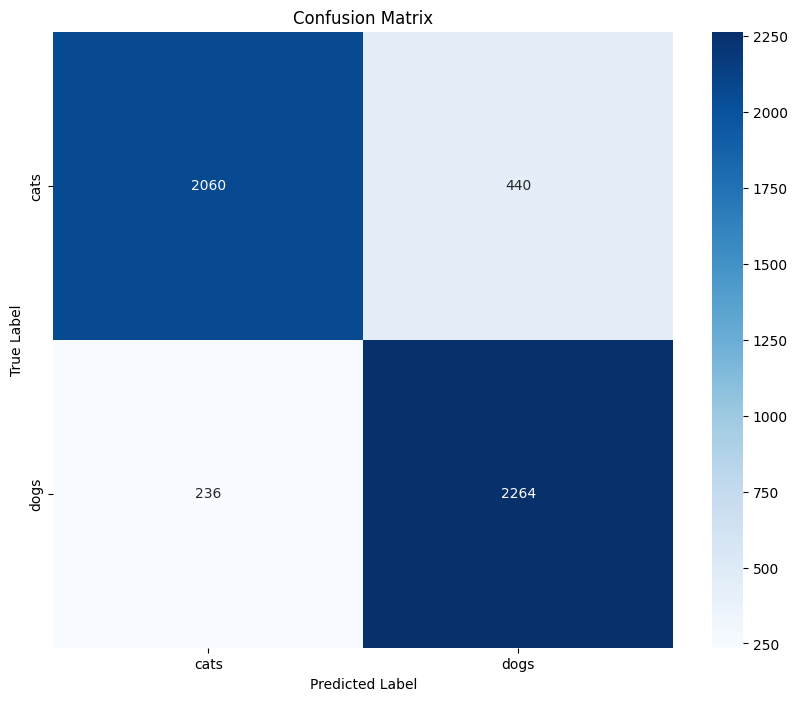

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


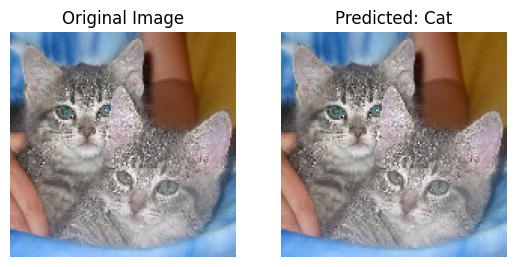

In [25]:
# Single Image Prediction
def make_prediction(img_path):
    img = load_img(img_path, target_size=(150,150))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # add batch dimension
    img_array /= 255
    # print(img_array.shape)
    prediction = model.predict(img_array)
    # print("Prediction", prediction)

    # Original Image
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    # Prediction
    plt.subplot(1,2,2)
    if prediction[0][0] > 0.5:
        plt.title("Predicted: Dog")
    else:
        plt.title("Predicted: Cat")
    plt.imshow(img)
    plt.axis("off")

    plt.show()
    
img_path = "/kaggle/input/dogsvscats/test/cats/cat.10021.jpg"
make_prediction(img_path)